## Elastic net sweep

In [ ]:
import wandb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use("clean_fig.mplstyle")

api = wandb.Api()

In [ ]:

sweep_id = "ekmd9isa"
sweep = api.sweep(f"jhrudoler-penn/inductive-bias/{sweep_id}")
run_stats = []
for run in sweep.runs:
    # print(f"Run ID: {run.id}, State: {run.state}, Name: {run.name}")
    run_stats.append({"id": run.id, "state": run.state, "name": run.name} | run.summary._json_dict | run.config) 
run_stats_df = pd.DataFrame(run_stats)
run_stats_df.to_csv(f"sweep_{sweep.name}_results.csv", index=False)



In [ ]:
run_stats_df

,id,state,name,_runtime,_step,_timestamp,_wandb,bias/lambda_1,bias/lambda_2,epoch,...,smooth,input_dim,l1_lambda,l1_smooth,l2_lambda,hidden_dim,output_dim,optimizer_cls,bias_model_kwargs,grad_match_loss_fn
0,jkc2esio,finished,vital-sweep-180,36.536425,221,1.749834e+09,{'runtime': 37},0.003484,0.306033,60,...,0.000001,10,10.0000,0.000001,10.0000,200,1,Adam,None,mse_loss
1,mp5sv6d6,finished,good-sweep-179,36.767301,221,1.749834e+09,{'runtime': 37},-0.003811,0.308742,60,...,0.000010,10,10.0000,0.000010,10.0000,200,1,Adam,None,mse_loss
2,a3ucl01p,finished,gentle-sweep-178,60.151803,344,1.749834e+09,{'runtime': 60},-0.003837,-3.065856,109,...,0.000100,10,10.0000,0.000100,10.0000,200,1,Adam,None,mse_loss
3,dt6gudxy,finished,prime-sweep-176,36.455948,221,1.749834e+09,{'runtime': 37},-1.502499,-1.500149,60,...,0.010000,10,10.0000,0.010000,10.0000,200,1,Adam,None,mse_loss
4,bfln952e,finished,stellar-sweep-177,36.944494,221,1.749834e+09,{'runtime': 37},0.637172,0.635509,60,...,0.001000,10,10.0000,0.001000,10.0000,200,1,Adam,None,mse_loss
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,zwsfosat,finished,dutiful-sweep-5,46.668944,278,1.749829e+09,{'runtime': 47},0.002124,0.004864,80,...,0.000001,10,0.0001,0.000001,0.0001,200,1,Adam,None,mse_loss
176,gqtysl1q,finished,vague-sweep-4,46.000448,278,1.749829e+09,{'runtime': 46},0.002124,0.004864,80,...,0.000010,10,0.0001,0.000010,0.0001,200,1,Adam,None,mse_loss
177,gguvo1wv,finished,feasible-sweep-3,46.590093,278,1.749829e+09,{'runtime': 47},0.002100,0.004884,80,...,0.000100,10,0.0001,0.000100,0.0001,200,1,Adam,None,mse_loss
178,hk1cmsuf,finished,misunderstood-sweep-2,46.708193,278,1.749829e+09,{'runtime': 47},0.002016,0.004982,80,...,0.001000,10,0.0001,0.001000,0.0001,200,1,Adam,None,mse_loss


KeyError: 'value'

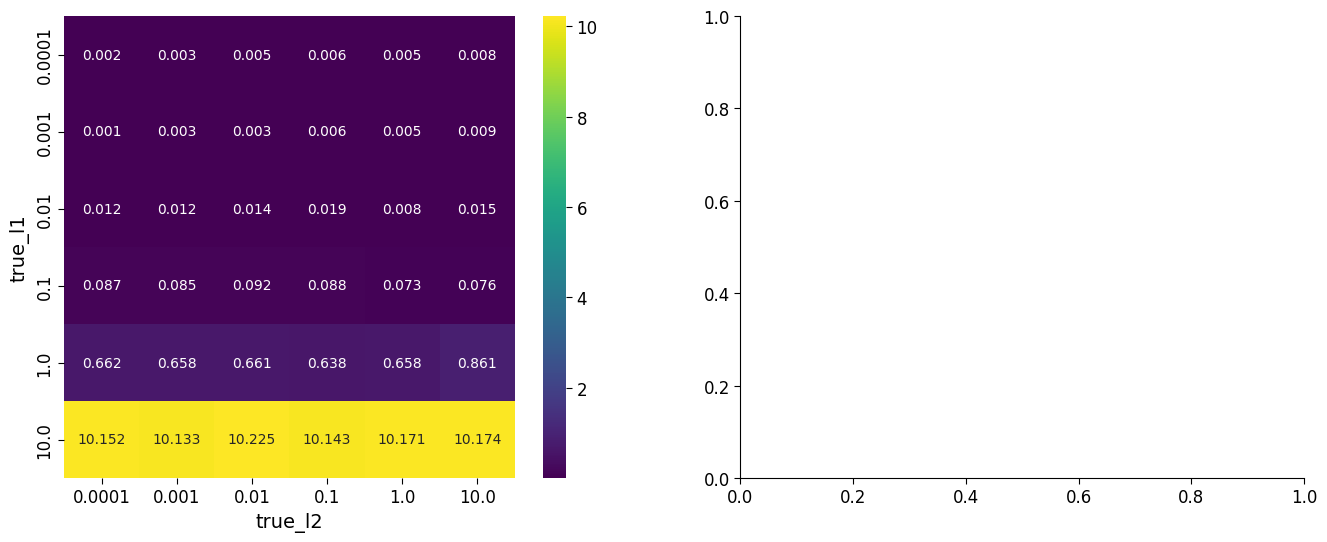

In [ ]:
# Load your sweep results
df = pd.read_csv(f"sweep_{sweep.name}_results.csv")

# Rename for clarity
df = df.rename(columns={
    "l1": "true_l1",
    "l2": "true_l2",
    "bias/lambda_1": "estimated_l1",
    "bias/lambda_2": "estimated_l2"
})

# Compute errors
df["l1_error"] = (df["true_l1"] - df["estimated_l1"]).abs()
df["l2_error"] = (df["true_l2"] - df["estimated_l2"]).abs()
df["total_error"] = df["l1_error"] + df["l2_error"]


# ---- HEATMAPS: L1 and L2 Error ----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# L1 Error Heatmap
heatmap_l1 = df.pivot_table(index="true_l1", columns="true_l2", values="l1_error")
sns.heatmap(heatmap_l1, annot=True, fmt=".3f", cmap="viridis", ax=axes[0])
axes[0].set_title(f"L1 Bias Recovery Error \n Smoothing: $\\beta = {sweep.config['parameters']['smooth']['value']}$")
axes[0].set_xlabel("True L2")
axes[0].set_ylabel("True L1")
axes[0].invert_yaxis()

# L2 Error Heatmap
heatmap_l2 = df.pivot_table(index="true_l1", columns="true_l2", values="l2_error")
sns.heatmap(heatmap_l2, annot=True, fmt=".3f", cmap="viridis", ax=axes[1])
axes[1].set_title(f"L2 Bias Recovery Error \n Smoothing: $\\beta = {sweep.config['parameters']['smooth']['value']}$")
axes[1].set_xlabel("True L2")
axes[1].set_ylabel("True L1")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()
fig.savefig(f"sweep_{sweep.name}_elasticnet_estimation_heatmap.pdf")

from matplotlib.colors import LogNorm

# ---- SCATTER: Estimated vs True L1 and L2 ----
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Scatter plot for L1
norm_l1 = LogNorm(
    vmin=df["true_l2"].min(),
    vmax=df["true_l2"].max()
)
sns.scatterplot(x="true_l1", y="estimated_l1", hue="true_l2", hue_norm=norm_l1, data=df, ax=axes[0])
axes[0].plot([df["true_l1"].min(), df["true_l1"].max()],
         [df["true_l1"].min(), df["true_l1"].max()], linestyle="--", color="gray")
axes[0].set_title(f"Estimated vs True L1 \n Smoothing: $\\beta = {sweep.config['parameters']['smooth']['value']}$", pad=20)
axes[0].set_xlabel("True L1")
axes[0].set_ylabel("Estimated L1")
axes[0].set_xscale('log')
axes[0].set_yscale('log')

# # annotate the plots with the smoothing value beta
# axes[0].annotate(
#     f"L1 smoothing: $\\beta = {sweep.config["parameters"]["smooth"]["value"]}$",
#     xy=(0.5, 0.95), xycoords="axes fraction",
#     fontsize=12, ha="center"
# )

# Scatter plot for L2
norm_l2 = LogNorm(
    vmin=df["true_l1"].min(),
    vmax=df["true_l1"].max()
)
sns.scatterplot(x="true_l2", y="estimated_l2", hue="true_l1", hue_norm=norm_l2, data=df, ax=axes[1])
axes[1].plot([df["true_l2"].min(), df["true_l2"].max()],
         [df["true_l2"].min(), df["true_l2"].max()], linestyle="--", color="gray")
axes[1].set_title(f"Estimated vs True L2 \n Smoothing: $\\beta = {sweep.config['parameters']['smooth']['values']}$", pad=20)
axes[1].set_xlabel("True L2")
axes[1].set_ylabel("Estimated L2")
axes[1].set_xscale('log')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()
# Save the figure
fig.savefig(f"sweep_{sweep.name}_elasticnet_estimation_scatter.pdf")


In [ ]:
# Load your sweep results
df = pd.read_csv(f"sweep_{sweep.name}_results.csv")

# Rename for clarity
df = df.rename(columns={
    "l1": "true_l1",
    "l2": "true_l2",
    "bias/lambda_1": "estimated_l1",
    "bias/lambda_2": "estimated_l2"
})

# Compute errors
df["l1_error"] = (df["true_l1"] - df["estimated_l1"]).abs()
df["l2_error"] = (df["true_l2"] - df["estimated_l2"]).abs()
df["total_error"] = df["l1_error"] + df["l2_error"]

grouped_by_smooth = df.groupby("smooth")

# ---- HEATMAPS: L1 and L2 Error ----
n_rows = len(grouped_by_smooth)
fig, axes = plt.subplots(n_rows, 2, figsize=(12, 4.5 * n_rows), squeeze=False)
for idx, (smooth_value, group_df) in enumerate(grouped_by_smooth):
    # L1 Error Heatmap
    heatmap_l1 = group_df.pivot_table(index="true_l1", columns="true_l2", values="l1_error")
    sns.heatmap(heatmap_l1, annot=True, fmt=".3f", cmap="viridis", ax=axes[idx, 0])
    axes[idx, 0].set_title(f"L1 Bias Recovery Error \n Smoothing: $\\beta = {smooth_value}$")
    axes[idx, 0].set_xlabel("True L2")
    axes[idx, 0].set_ylabel("True L1")
    axes[idx, 0].invert_yaxis()

    # L2 Error Heatmap
    heatmap_l2 = group_df.pivot_table(index="true_l1", columns="true_l2", values="l2_error")
    sns.heatmap(heatmap_l2, annot=True, fmt=".3f", cmap="viridis", ax=axes[idx, 1])
    axes[idx, 1].set_title(f"L2 Bias Recovery Error \n Smoothing: $\\beta = {smooth_value}$")
    axes[idx, 1].set_xlabel("True L2")
    axes[idx, 1].set_ylabel("True L1")
    axes[idx, 1].invert_yaxis()

plt.show()
fig.savefig(f"sweep_{sweep.name}_elasticnet_estimation_heatmap.pdf")

from matplotlib.colors import LogNorm

# ---- SCATTER: Estimated vs True L1 and L2 ----
n_rows = len(grouped_by_smooth)
fig, axes = plt.subplots(n_rows, 2, figsize=(12, 4.5 * n_rows), squeeze=False)
for idx, (smooth_value, group_df) in enumerate(grouped_by_smooth):
    norm_l1 = LogNorm(
        vmin=group_df["true_l2"].min(),
        vmax=group_df["true_l2"].max()
    )
    norm_l2 = LogNorm(
        vmin=group_df["true_l1"].min(),
        vmax=group_df["true_l1"].max()
    )
    sns.scatterplot(x="true_l1", y="estimated_l1", hue="true_l2", hue_norm=norm_l1, data=group_df, ax=axes[idx, 0])
    axes[idx, 0].plot([group_df["true_l1"].min(), group_df["true_l1"].max()],
            [group_df["true_l1"].min(), group_df["true_l1"].max()], linestyle="--", color="gray")
    axes[idx, 0].set_title(f"Estimated vs True L1 \n Smoothing: $\\beta = {smooth_value}$", pad=20)
    axes[idx, 0].set_xlabel("True L1")
    axes[idx, 0].set_ylabel("Estimated L1")
    axes[idx, 0].set_xscale('log')
    axes[idx, 0].set_yscale('log')

plt.show()
# Save the figure
fig.savefig(f"sweep_{sweep.name}_elasticnet_estimation_scatter.pdf")

NameError: name 'pd' is not defined

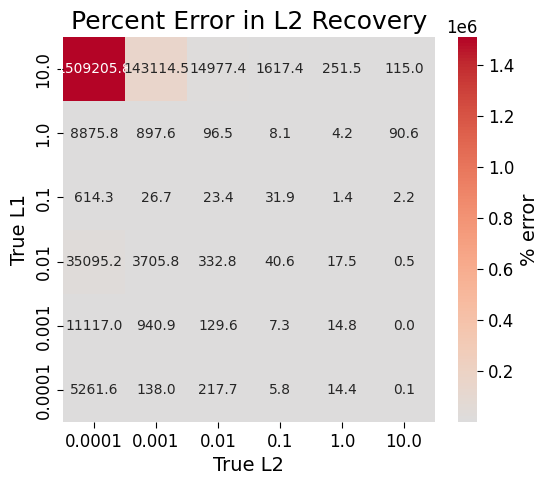

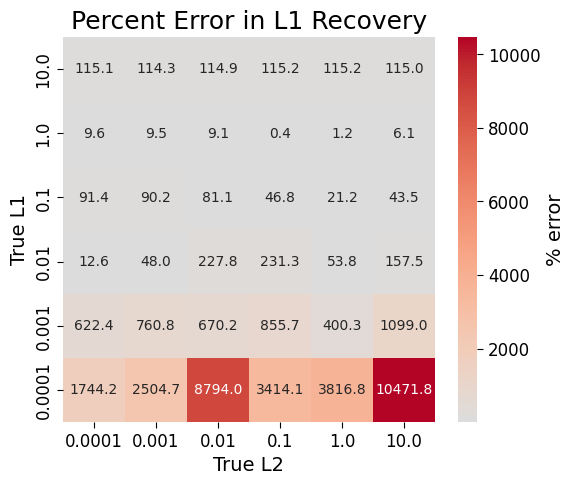

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# assume `err` is a DataFrame indexed by (true_l1, true_l2) with columns:
#   'abs_error' = |estimated−true|, and 'true' = true error
err = df.pivot(index="true_l1", columns="true_l2", values="l2_error")  # or estimated_l1, whichever
true_vals = df.pivot(index="true_l1", columns="true_l2", values="true_l2")  # or true_l1, whichever

# compute percent error
pct = err / true_vals * 100

plt.figure(figsize=(6, 5))
sns.heatmap(
    pct,
    annot=True,
    fmt=".1f",
    cmap="coolwarm",
    center=0,
    cbar_kws={"label": "% error"}
)
plt.xlabel("True L2")
plt.ylabel("True L1")
plt.title("Percent Error in L2 Recovery")
plt.gca().invert_yaxis()
# plt.tight_layout()
plt.show()

# repeat for L1 error
err_l1 = df.pivot(index="true_l1", columns="true_l2", values="l1_error")
true_vals_l1 = df.pivot(index="true_l1", columns="true_l2", values="true_l1")  # or true_l2, whichever
# compute percent error
pct_l1 = (err_l1) / true_vals_l1 * 100
plt.figure(figsize=(6, 5))
sns.heatmap(
    pct_l1,
    annot=True,
    fmt=".1f",
    cmap="coolwarm",
    center=0,
    cbar_kws={"label": "% error"}
)
plt.xlabel("True L2")
plt.ylabel("True L1")
plt.title("Percent Error in L1 Recovery")
plt.gca().invert_yaxis()
# plt.tight_layout()
plt.show()

In [ ]:
import yaml


def read_config(path: str):
    """read yaml file"""
    with open(path, 'r') as f:
        data = yaml.safe_load(f)
    return data

In [ ]:
config = read_config("elasticnet_sweep_config.yaml")

In [ ]:
config["parameters"]["smooth"]["values"]

[0.01, 0.001, 0.0001, 1e-05, 1e-06]